## Analisando o OEM-FSS dataset

Total de máscaras encontradas: 50


Processando Máscaras:   0%|          | 0/50 [00:00<?, ?it/s]

,image_name,patch_x,patch_y,total_pixels,class_0,class_1,class_2,class_4,class_5,class_7,class_8,class_11,class_6,class_9,class_10,class_3
0,kyoto_68.tif,0,0,160000,37494,3275,6086,72781,27358,7819,727,4460,0,0,0,0
1,kyoto_68.tif,312,0,160000,80190,7990,9942,18245,22551,12519,6763,1800,0,0,0,0
2,kyoto_68.tif,624,0,160000,93813,23312,7600,0,17973,17302,0,0,0,0,0,0
3,kyoto_68.tif,0,312,160000,73444,3077,1963,32252,18938,23459,0,6867,0,0,0,0
4,kyoto_68.tif,312,312,160000,121500,9199,3189,0,12133,13979,0,0,0,0,0,0


/tmp/ipykernel_157718/178630470.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=presence_df.index, y=presence_df.values, palette="viridis")


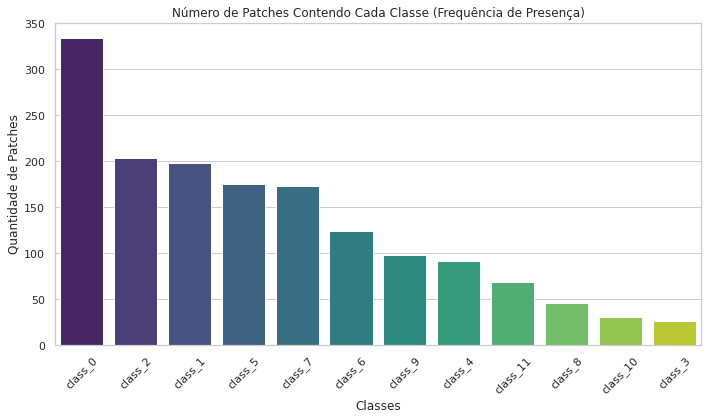

/tmp/ipykernel_157718/178630470.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_pixels_per_class.index, y=total_pixels_per_class.values, palette="mako")


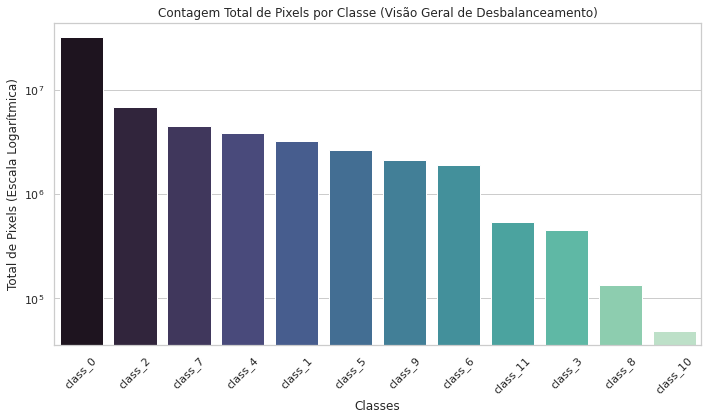

In [2]:
import os
import glob
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# ==========================================
# 1. Configurações e Parâmetros
# ==========================================
MASK_DIR = '/scratch/matheuspimenta/oem/valset/labels/' # Altere para o seu diretório
WINDOW_SIZE = 400
STRIDE = 312

# Busca todas as máscaras .tif no diretório
mask_files = glob.glob(os.path.join(MASK_DIR, '*.tif'))
print(f"Total de máscaras encontradas: {len(mask_files)}")

# ==========================================
# 2. Processamento com Janela Deslizante
# ==========================================
data_records = []

for mask_path in tqdm(mask_files, desc="Processando Máscaras"):
    filename = os.path.basename(mask_path)
    
    with rasterio.open(mask_path) as src:
        # Lê a primeira banda (assumindo que a máscara tem apenas 1 canal)
        mask = src.read(1) 
        
    h, w = mask.shape
    
    # Ignora imagens menores que a janela
    if h < WINDOW_SIZE or w < WINDOW_SIZE:
        continue
        
    # Janela deslizante
    for y in range(0, h - WINDOW_SIZE + 1, STRIDE):
        for x in range(0, w - WINDOW_SIZE + 1, STRIDE):
            
            # Recorta o patch 400x400
            patch = mask[y:y+WINDOW_SIZE, x:x+WINDOW_SIZE]
            
            # Conta a frequência de cada classe no patch
            classes, counts = np.unique(patch, return_counts=True)
            
            # Dicionário base para este patch
            record = {
                'image_name': filename,
                'patch_x': x,
                'patch_y': y,
                'total_pixels': WINDOW_SIZE * WINDOW_SIZE
            }
            
            # Adiciona a contagem de pixels de cada classe
            for cls, count in zip(classes, counts):
                record[f'class_{cls}'] = count
                
            data_records.append(record)

# ==========================================
# 3. Construção do DataFrame
# ==========================================
df = pd.DataFrame(data_records)

# Preenche NaN com 0 (patches onde uma determinada classe não apareceu)
df = df.fillna(0)

# Opcional: Converter colunas de classes para inteiros
class_cols = [col for col in df.columns if col.startswith('class_')]
df[class_cols] = df[class_cols].astype(int)

display(df.head())

# ==========================================
# 4. Visualizações e Gráficos
# ==========================================
sns.set_theme(style="whitegrid")

# Gráfico 1: Quantidade total de patches que contêm pelo menos 1 pixel de cada classe
plt.figure(figsize=(10, 6))
presence_df = (df[class_cols] > 0).sum().sort_values(ascending=False)
sns.barplot(x=presence_df.index, y=presence_df.values, palette="viridis")
plt.title('Número de Patches Contendo Cada Classe (Frequência de Presença)')
plt.ylabel('Quantidade de Patches')
plt.xlabel('Classes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Gráfico 2: Proporção total de pixels por classe no dataset (útil para analisar desbalanceamento)
plt.figure(figsize=(10, 6))
total_pixels_per_class = df[class_cols].sum().sort_values(ascending=False)
sns.barplot(x=total_pixels_per_class.index, y=total_pixels_per_class.values, palette="mako")
plt.title('Contagem Total de Pixels por Classe (Visão Geral de Desbalanceamento)')
plt.ylabel('Total de Pixels (Escala Logarítmica)')
plt.xlabel('Classes')
plt.yscale('log') # Escala logarítmica ajuda a visualizar classes muito raras vs muito frequentes
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
import json
import os
import rasterio
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

# ==========================================
# 1. Configurações Iniciais
# ==========================================
JSON_PATH = '/scratch/matheuspimenta/oem/val.json' # Altere para o caminho real do seu JSON
MASK_DIR = '/scratch/matheuspimenta/oem/valset/labels/' # Altere para o diretório real das máscaras
TARGET_CLASSES = [8, 9, 10, 11]

# Carregando o JSON
with open(JSON_PATH, 'r') as f:
    valset_data = json.load(f)

# ==========================================
# 2. Avaliação do Conjunto de Suporte
# ==========================================
support_records = []

# O JSON usa strings para as chaves ('8', '9', etc.)
for class_str, files in valset_data['support_set'].items():
    class_id = int(class_str)
    
    if class_id not in TARGET_CLASSES:
        continue
        
    for filename in files:
        filepath = os.path.join(MASK_DIR, filename)
        
        # Verifica se o arquivo existe para evitar quebrar o loop
        if not os.path.exists(filepath):
            print(f"[Aviso] Arquivo de suporte não encontrado: {filepath}")
            continue
            
        with rasterio.open(filepath) as src:
            mask = src.read(1)
            
        # Conta quantos pixels da classe alvo existem nesta imagem de suporte
        target_pixels = np.sum(mask == class_id)
        total_pixels = mask.size
        
        support_records.append({
            'role': 'support',
            'target_class': class_id,
            'filename': filename,
            'target_pixels': target_pixels,
            'proportion_%': (target_pixels / total_pixels) * 100
        })

df_support = pd.DataFrame(support_records)
print("=== Resumo do Conjunto de Suporte ===")
display(df_support)

# ==========================================
# 3. Avaliação do Conjunto de Query
# ==========================================
query_records = []

# Avaliando cada query listada no JSON
for filename in tqdm(valset_data['query_set'], desc="Avaliando Queries"):
    filepath = os.path.join(MASK_DIR, filename)
    
    if not os.path.exists(filepath):
        print(f"[Aviso] Arquivo de query não encontrado: {filepath}")
        continue
        
    with rasterio.open(filepath) as src:
        mask = src.read(1)
        
    total_pixels = mask.size
    
    # Registro base para esta imagem de query
    record = {
        'role': 'query',
        'filename': filename,
        'total_pixels': total_pixels
    }
    
    # Checa a presença e contagem de todas as classes alvo na mesma query
    for class_id in TARGET_CLASSES:
        pixels_of_class = np.sum(mask == class_id)
        record[f'class_{class_id}_pixels'] = pixels_of_class
        record[f'has_class_{class_id}'] = bool(pixels_of_class > 0)
        
    query_records.append(record)

df_query = pd.DataFrame(query_records)
print("\n=== Resumo do Conjunto de Query ===")
display(df_query.head(10))

# ==========================================
# 4. Análise de Presença nas Queries
# ==========================================
# Quantas queries contêm cada uma das classes de interesse?
presence_cols = [f'has_class_{c}' for c in TARGET_CLASSES]
query_presence_summary = df_query[presence_cols].sum().reset_index()
query_presence_summary.columns = ['Classe', 'Qtd de Queries que a contêm']
query_presence_summary['Classe'] = query_presence_summary['Classe'].str.extract(r'(\d+)').astype(int)

print("\n=== Presença das Classes no Query Set ===")
display(query_presence_summary)

=== Resumo do Conjunto de Suporte ===


,role,target_class,filename,target_pixels,proportion_%
0,support,8,dhaka_30.tif,35135,3.350735
1,support,8,al_qurnah_30.tif,5208,0.496674
2,support,8,lubuskie_11.tif,220,0.020981
3,support,8,rotterdam_39.tif,1154,0.142469
4,support,8,rotterdam_5.tif,2062,0.254568
5,support,9,rotterdam_19.tif,119913,14.804074
6,support,9,rotterdam_8.tif,11773,1.453457
7,support,9,christchurch_60.tif,119920,11.436462
8,support,9,rotterdam_16.tif,43627,5.386049
9,support,9,rosario_10.tif,8656,0.825500


Avaliando Queries:   0%|          | 0/30 [00:00<?, ?it/s]


=== Resumo do Conjunto de Query ===


,role,filename,total_pixels,class_8_pixels,has_class_8,class_9_pixels,has_class_9,class_10_pixels,has_class_10,class_11_pixels,has_class_11
0,query,lohur_7.tif,1048576,1546,True,19954,True,0,False,17661,True
1,query,monrovia_29.tif,1048576,0,False,234414,True,0,False,3388,True
2,query,al_qurnah_62.tif,1048576,0,False,10821,True,0,False,0,False
3,query,svaneti_13.tif,1048576,0,False,8068,True,0,False,35184,True
4,query,kyoto_18.tif,1048576,1295,True,0,False,0,False,37562,True
5,query,lohur_11.tif,1048576,0,False,14538,True,0,False,19010,True
6,query,maputo_6.tif,1048576,3957,True,14905,True,0,False,0,False
7,query,rio_7.tif,178234,0,False,0,False,670,True,0,False
8,query,kyoto_68.tif,1048576,6763,True,0,False,0,False,11121,True
9,query,rotterdam_21.tif,810000,3840,True,37036,True,0,False,0,False



=== Presença das Classes no Query Set ===


,Classe,Qtd de Queries que a contêm
0,8,17
1,9,20
2,10,8
3,11,12


In [6]:
df_query.head(50)

,role,filename,total_pixels,class_8_pixels,has_class_8,class_9_pixels,has_class_9,class_10_pixels,has_class_10,class_11_pixels,has_class_11
0,query,lohur_7.tif,1048576,1546,True,19954,True,0,False,17661,True
1,query,monrovia_29.tif,1048576,0,False,234414,True,0,False,3388,True
2,query,al_qurnah_62.tif,1048576,0,False,10821,True,0,False,0,False
3,query,svaneti_13.tif,1048576,0,False,8068,True,0,False,35184,True
4,query,kyoto_18.tif,1048576,1295,True,0,False,0,False,37562,True
5,query,lohur_11.tif,1048576,0,False,14538,True,0,False,19010,True
6,query,maputo_6.tif,1048576,3957,True,14905,True,0,False,0,False
7,query,rio_7.tif,178234,0,False,0,False,670,True,0,False
8,query,kyoto_68.tif,1048576,6763,True,0,False,0,False,11121,True
9,query,rotterdam_21.tif,810000,3840,True,37036,True,0,False,0,False


In [7]:
df_query.to_csv('query_analysis.csv', index=False)

In [8]:
QUERY_FILES = valset_data['query_set'] # Substitua pela sua lista de arquivos (ex: valset_data['query_set'])

WINDOW_SIZE = 400
STRIDE = 312
TARGET_CLASSES = [8, 9, 10, 11]

# 10% da área de uma imagem 400x400 (160.000 pixels)
THRESHOLD_PERCENT = 0.10
PIXELS_THRESHOLD = (WINDOW_SIZE * WINDOW_SIZE) * THRESHOLD_PERCENT 

print(f"Total de pixels por patch: {WINDOW_SIZE * WINDOW_SIZE}")
print(f"Limiar de 10% (mínimo de pixels exigido): {int(PIXELS_THRESHOLD)}")

# ==========================================
# 2. Extração com Janela Deslizante
# ==========================================
patch_records = []

for filename in tqdm(QUERY_FILES, desc="Processando Imagens"):
    filepath = os.path.join(MASK_DIR, filename)
    
    if not os.path.exists(filepath):
        continue
        
    with rasterio.open(filepath) as src:
        mask = src.read(1)
        
    h, w = mask.shape
    
    # Ignora imagens menores que a janela
    if h < WINDOW_SIZE or w < WINDOW_SIZE:
        continue
        
    for y in range(0, h - WINDOW_SIZE + 1, STRIDE):
        for x in range(0, w - WINDOW_SIZE + 1, STRIDE):
            
            patch = mask[y:y+WINDOW_SIZE, x:x+WINDOW_SIZE]
            
            # Registro base da janela atual
            record = {
                'image_name': filename,
                'patch_y': y,
                'patch_x': x,
                'valid_patch': False # Será True se qualquer classe bater os 10%
            }
            
            # Avalia a presença das classes de suporte
            for class_id in TARGET_CLASSES:
                pixels_count = np.sum(patch == class_id)
                meets_threshold = pixels_count >= PIXELS_THRESHOLD
                
                # Salva os dados brutos e booleanos
                record[f'class_{class_id}_pixels'] = pixels_count
                record[f'class_{class_id}_valid'] = meets_threshold
                
                # Se bater o limiar para essa classe, a janela inteira é marcada como útil
                if meets_threshold:
                    record['valid_patch'] = True
                    
            patch_records.append(record)

# ==========================================
# 3. Análise dos Resultados
# ==========================================
df_patches = pd.DataFrame(patch_records)

# Filtrando apenas os patches que possuem >= 10% de PELO MENOS uma das classes
df_valid_patches = df_patches[df_patches['valid_patch'] == True].copy()

print(f"\nTotal de patches gerados: {len(df_patches)}")
print(f"Total de patches válidos (>= 10% de alguma classe alvo): {len(df_valid_patches)}")
print(f"Taxa de aproveitamento: {(len(df_valid_patches) / len(df_patches)) * 100:.2f}%")

display(df_valid_patches.head())

Total de pixels por patch: 160000
Limiar de 10% (mínimo de pixels exigido): 16000


Processando Imagens:   0%|          | 0/30 [00:00<?, ?it/s]


Total de patches gerados: 216
Total de patches válidos (>= 10% de alguma classe alvo): 29
Taxa de aproveitamento: 13.43%


,image_name,patch_y,patch_x,valid_patch,class_8_pixels,class_8_valid,class_9_pixels,class_9_valid,class_10_pixels,class_10_valid,class_11_pixels,class_11_valid
9,monrovia_29.tif,0,0,True,0,False,46472,True,0,False,0,False
10,monrovia_29.tif,0,312,True,0,False,36922,True,0,False,0,False
11,monrovia_29.tif,0,624,True,0,False,51258,True,0,False,0,False
12,monrovia_29.tif,312,0,True,0,False,55311,True,0,False,0,False
13,monrovia_29.tif,312,312,True,0,False,46421,True,0,False,0,False


In [9]:
df_valid_patches.head(30)

,image_name,patch_y,patch_x,valid_patch,class_8_pixels,class_8_valid,class_9_pixels,class_9_valid,class_10_pixels,class_10_valid,class_11_pixels,class_11_valid
9,monrovia_29.tif,0,0,True,0,False,46472,True,0,False,0,False
10,monrovia_29.tif,0,312,True,0,False,36922,True,0,False,0,False
11,monrovia_29.tif,0,624,True,0,False,51258,True,0,False,0,False
12,monrovia_29.tif,312,0,True,0,False,55311,True,0,False,0,False
13,monrovia_29.tif,312,312,True,0,False,46421,True,0,False,0,False
14,monrovia_29.tif,312,624,True,0,False,47642,True,0,False,19,False
15,monrovia_29.tif,624,0,True,0,False,32500,True,0,False,0,False
27,svaneti_13.tif,0,0,True,0,False,0,False,0,False,18331,True
28,svaneti_13.tif,0,312,True,0,False,0,False,0,False,22313,True
40,kyoto_18.tif,312,312,True,0,False,0,False,0,False,23129,True
